In [1]:
import os
os.environ["RAY_TRAIN_V2_ENABLED"] = "1"
os.environ["TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S"] = "0" # Disable excessive checkpoint sync warning
import multiprocess as mp
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset #, IterableDataset, TensorDataset
from sklearn.preprocessing import StandardScaler

import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping
# from lightning.pytorch.loggers import TensorBoardLogger, WandbLogger

from functools import partial
import numpy as np
import pandas as pd
import datetime as dt
from dateutil.relativedelta import relativedelta
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# from NowcastingPipelineM import NowcastingPH_M/
# import dynamicfactoranalysis.dynamicfactoranalysis as dfa
from STSeq2One import STMFSeq2One, STMFSeq2OneLightning
from MTSeq2One import MTMFSeq2One, MTMFSeq2OneLightning #MTMFSeq2OneOLD, MTMFSeq2OneLightningOLD 
from data_utils import NowcastingLSTM_MQ, sliding_windows_ST, sliding_windows_MT # get_dataloader_for_vintage
# from train_vintage import train_one_vintage, train_model
# from evaluate_vintage import evaluate_one_vintage, evaluate_one_vintage_MT

import ray
from ray import tune
from ray.tune.search import ConcurrencyLimiter
from ray.tune.search.optuna import OptunaSearch
# from ray.tune.schedulers import ASHAScheduler
from ray.tune.integration.pytorch_lightning import TuneReportCheckpointCallback
# from ray.train.lightning import RayDDPStrategy,RayLightningEnvironment,RayTrainReportCallback,prepare_trainer

In [2]:
# ray.shutdown()
ray.init(log_to_driver=False, logging_level="ERROR") #runtime_env={"working_dir": "/home/btiu/Documents/Research/TweetsNowcast"}

Python version:,3.10.16
Ray version:,2.47.0
Dashboard:,http://127.0.0.1:8265


In [5]:
def get_dataloader_for_vintage(vintage, with_econ, with_tweets, kmpair, data_window, task, mode="train"):
    data_model = NowcastingLSTM_MQ()
    data, target_scaler, econ_scaler, tweets_scaler = data_model.load_data(vintage=vintage,window=1000, kmpair=kmpair, with_econ=with_econ, with_tweets=with_tweets, target_release_lag=True,scaled=True, extend=False, DFM_order=(1,0,1,0), optimize_order = False, target='PHL_GDP_SA')
    data = data.dropna()
    train_data = data.iloc[:-3] # [:-3] for no bias during training, [:] for bias during training
    val_data = data.iloc[-data_window-3:]
    # val_data, _, _, _ = data_model.load_data(vintage=vintage+pd.offsets.QuarterEnd(0)+pd.DateOffset(months=2),window=1000, kmpair=kmpair, with_econ=with_econ, with_tweets=with_tweets, target_release_lag=False, scaled=False, extend=False, DFM_order=(1,0,1,0), optimize_order = False, target='PHL_GDP_SA')
    # val_data = val_data.dropna().iloc[-data_window-3:]
    # val_data.iloc[:,:1] = target_scaler.transform(val_data.iloc[:,:1])
    # if with_econ and with_tweets:
    #     econ_n_feat = econ_scaler.n_features_in_
    #     tweets_n_feat = tweets_scaler.n_features_in_
    #     val_data.iloc[:,1:tweets_n_feat+1] = tweets_scaler.transform(val_data.iloc[:,1:tweets_n_feat+1])
    #     val_data.iloc[:,tweets_n_feat+1:] = econ_scaler.transform(val_data.iloc[:,tweets_n_feat+1:])
    # elif with_econ:
    #     econ_n_feat = econ_scaler.n_features_in_
    #     val_data.iloc[:,1:econ_n_feat+1] = econ_scaler.transform(val_data.iloc[:,1:econ_n_feat+1])
    # elif with_tweets:
    #     tweets_n_feat = tweets_scaler.n_features_in_
    #     val_data.iloc[:,1:tweets_n_feat+1] = tweets_scaler.transform(val_data.iloc[:,1:tweets_n_feat+1])

    if task == 'singletask':
        trainX_in, trainY_in, _, trainY_out = sliding_windows_ST(train_data, train=True, seq_length=data_window)
        valX_in, valY_in, _, valY_out = sliding_windows_ST(val_data, train=True, seq_length=data_window)
        train_dataset = TensorDataset(trainX_in, trainY_in, trainY_out)
        val_dataset = TensorDataset(valX_in, valY_in, valY_out)
    elif task == 'multitask':
        trainX_in, trainY_in, trainX_out, trainY_out = sliding_windows_MT(train_data, train=True, seq_length=data_window)
        valX_in, valY_in, valX_out, valY_out = sliding_windows_MT(val_data, train=True, seq_length=data_window)
        train_dataset = TensorDataset(trainX_in, trainY_in, trainX_out, trainY_out)
        val_dataset = TensorDataset(valX_in, valY_in, valX_out, valY_out)
    train_loader = DataLoader(train_dataset, batch_size=200, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=200, shuffle=False)
    
    return train_loader, val_loader, target_scaler, econ_scaler, tweets_scaler

In [6]:
def train_model(config, vintage, with_econ, with_tweets, kmpair, task, ckpt_path=None, logger_enabled=False, device='cpu'):
    pl.seed_everything(42, workers=True)
    train_loader, val_loader, _,_,_ = get_dataloader_for_vintage(vintage, with_econ, with_tweets, kmpair=kmpair, data_window = config['data_window'], task=task)
    if task == "singletask":
        model = STMFSeq2OneLightning(
            dim_x=train_loader.dataset.tensors[0].shape[-1],
            dim_y=train_loader.dataset.tensors[1].shape[-1],
            learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"],
            num_layers=config['num_layers'],
        )
        tune_callback = TuneReportCheckpointCallback(metrics={'val_loss_y': 'val_loss_y', 'train_loss': 'train_loss'})
    elif task == "multitask":
        model = MTMFSeq2OneLightning(
            dim_x=train_loader.dataset.tensors[0].shape[-1], # type: ignore
            dim_y=train_loader.dataset.tensors[1].shape[-1], # type: ignore
            num_layers=config['num_layers'],
            learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"],
            alpha=config['alpha']
        )
        tune_callback = TuneReportCheckpointCallback(metrics={'val_loss_y': 'val_loss_y', 'val_loss_x': 'val_loss_x', 'train_loss': 'train_loss'})
    # checkpoint_callback = ModelCheckpoint(dirpath=f"checkpoints/vintage_{vintage}", filename="model", save_top_k=1, monitor="val_loss_y", mode="min", save_last=True)
    checkpoint_callback = ModelCheckpoint(monitor="val_loss_y", mode="min", save_top_k=1, save_last=True)
    lr_monitor = LearningRateMonitor(logging_interval='step')
    trainer = pl.Trainer(
        max_epochs=config['epochs'],
        callbacks=[tune_callback] + ([checkpoint_callback, lr_monitor] if logger_enabled else []),
        enable_checkpointing=True,
        deterministic=True,
        accelerator=device,
        num_sanity_val_steps=0,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=logger_enabled,
        log_every_n_steps=1 if logger_enabled else 50
    )
    # tuner = Tuner(trainer)
    # lr_finder = tuner.lr_find(model, train_loader)
    # model.hparams.learning_rate = lr_finder.suggestion()
    # print(f"Suggested learning rate: {model.hparams.learning_rate}")
    if ckpt_path is not None:
        trainer.fit(model, train_loader, val_loader, ckpt_path = ckpt_path)
    else:
        trainer.fit(model, train_loader, val_loader)

In [7]:
def evaluate_one_vintage_ST(vintage, with_econ, with_tweets, kmpair, target, ckpt_path, config, device="cpu"):
    ### Train Scaler + Backcast/Test Data
    data_model = NowcastingLSTM_MQ()
    _, target_scaler, econ_scaler, tweets_scaler = data_model.load_data(vintage=vintage,window=1000, kmpair=kmpair, with_econ=with_econ, with_tweets=with_tweets, target_release_lag=True,scaled=True, extend=False, DFM_order=(1,0,1,0), optimize_order = False, target=target)
    test_data, _, _, _ = data_model.load_data(vintage=vintage, window=1000, kmpair=kmpair, with_econ=with_econ, with_tweets=with_tweets, target_release_lag=True,scaled=False, extend=True, DFM_order=(1,0,1,0), optimize_order = False, target=target)
    test_data = test_data.loc[vintage + relativedelta(months = -((vintage.month - 1) % 3) - config['data_window'] - (3 if vintage.month % 3 == 1 else 0), day=31):,:] # get first month of same qtr last year, but get final day. Extend one quarter if first month of quarter.
    test_data.iloc[:,:1] = target_scaler.transform(test_data.iloc[:,:1])
    if with_econ and with_tweets:
        econ_n_feat = econ_scaler.n_features_in_
        tweets_n_feat = tweets_scaler.n_features_in_
        test_data.iloc[:,1:tweets_n_feat+1] = tweets_scaler.transform(test_data.iloc[:,1:tweets_n_feat+1])
        test_data.iloc[:,tweets_n_feat+1:] = econ_scaler.transform(test_data.iloc[:,tweets_n_feat+1:])
    elif with_econ:
        econ_n_feat = econ_scaler.n_features_in_
        test_data.iloc[:,1:econ_n_feat+1] = econ_scaler.transform(test_data.iloc[:,1:econ_n_feat+1])
    elif with_tweets:
        tweets_n_feat = tweets_scaler.n_features_in_
        test_data.iloc[:,1:tweets_n_feat+1] = tweets_scaler.transform(test_data.iloc[:,1:tweets_n_feat+1])

    x_encoder_in, y_decoder_in, _, _ = sliding_windows_ST(test_data, train=False, seq_length=config['data_window'])
    testX_in = torch.Tensor(x_encoder_in)#.to(device)
    testY_in = torch.Tensor(y_decoder_in)#.to(device)

    lightning_model = STMFSeq2OneLightning.load_from_checkpoint(checkpoint_path=ckpt_path, model=STMFSeq2One(dim_x=testX_in.shape[-1], dim_y=testY_in.shape[-1], num_layers=config['num_layers']))
    lightning_model = lightning_model.to(device)
    lightning_model.eval()
    with torch.no_grad():
        start_row = 3 if vintage.month % 3 == 1 else 0
        # start_row = 0       # start_row = 3 if vintage.month % 3 == 1 else 0 ### whether to start from the first row or the fourth row
        if vintage.month % 3 == 1:
            backcastY = lightning_model(testX_in[:,:-3],testY_in[:,:-1])
            testY_in[:,-2] = backcastY[0,-1]
            # testY_in[:,-2] = backcastY[0][-1]
        nowcastY = lightning_model(testX_in[:,start_row:],testY_in[:,start_row//3:])
        nowcastY = target_scaler.inverse_transform(nowcastY[0].cpu().numpy())
    return (vintage, nowcastY.flatten()[-1])

In [8]:
def evaluate_one_vintage_MT(vintage, with_econ, with_tweets, kmpair, target, ckpt_path, config, device="cpu"):
    ### Train Scaler + Backcast/Test Data
    data_model = NowcastingLSTM_MQ()
    _, target_scaler, econ_scaler, tweets_scaler = data_model.load_data(vintage=vintage,window=1000, kmpair=kmpair, with_econ=with_econ, with_tweets=with_tweets, target_release_lag=True,scaled=True, extend=False, DFM_order=(1,0,1,0), optimize_order = False, target=target)
    test_data, _, _, _ = data_model.load_data(vintage=vintage, window=1000, kmpair=kmpair, with_econ=with_econ, with_tweets=with_tweets, target_release_lag=True,scaled=False, extend=False, DFM_order=(1,0,1,0), optimize_order = False, target=target)
    test_data = test_data.loc[vintage + relativedelta(months = -((vintage.month - 1) % 3) - config['data_window'] - (3 if vintage.month % 3 == 1 else 0), day=31):,:] # get first month of same qtr last year, but get final day. Extend one quarter if first month of quarter.
    test_data.iloc[:,:1] = target_scaler.transform(test_data.iloc[:,:1])
    if with_econ and with_tweets:
        econ_n_feat = econ_scaler.n_features_in_
        tweets_n_feat = tweets_scaler.n_features_in_
        test_data.iloc[:,1:tweets_n_feat+1] = tweets_scaler.transform(test_data.iloc[:,1:tweets_n_feat+1])
        test_data.iloc[:,tweets_n_feat+1:] = econ_scaler.transform(test_data.iloc[:,tweets_n_feat+1:])
    elif with_econ:
        econ_n_feat = econ_scaler.n_features_in_
        test_data.iloc[:,1:econ_n_feat+1] = econ_scaler.transform(test_data.iloc[:,1:econ_n_feat+1])
    elif with_tweets:
        tweets_n_feat = tweets_scaler.n_features_in_
        test_data.iloc[:,1:tweets_n_feat+1] = tweets_scaler.transform(test_data.iloc[:,1:tweets_n_feat+1])

    x_encoder_in, y_decoder_in, _, _ = sliding_windows_MT(test_data, train=False, seq_length=config['data_window'])
    testX_in = torch.Tensor(x_encoder_in)#.to(device)
    testY_in = torch.Tensor(y_decoder_in)#.to(device)

    # lightning_model = MTMFSeq2OneLightning.load_from_checkpoint(checkpoint_path=f"lightning_logs/version{version}/checkpoints/model.ckpt", model=model) # checkpoints/vintage_{vintage}/model{version}.ckpt
    lightning_model = MTMFSeq2OneLightning.load_from_checkpoint(checkpoint_path=ckpt_path, model=MTMFSeq2One(dim_x=testX_in.shape[-1], dim_y=testY_in.shape[-1], num_layers=config['num_layers']))
    lightning_model = lightning_model.to(device)
    lightning_model.eval()
    with torch.no_grad():
        # start_row = 3 if vintage.month % 3 == 1 else 0
        start_row = 0       # start_row = 3 if vintage.month % 3 == 1 else 0 ### whether to start from the first row or the fourth row
        if vintage.month % 3 == 1:
            latent = lightning_model.model.encoder_x(testX_in[:,:-3]) # Encode the input sequence excluding the last 3 columns
            backcastX = lightning_model.model.decoder_x(latent)
            nan_mask = torch.isnan(testX_in[0, -4])                 # Find NaNs in the second to the last row of testX_in
            testX_in[0, -4][nan_mask] = backcastX[0, -1][nan_mask]  # Take last row of backcast and replace NaNs
            _, backcastY = lightning_model(testX_in[:,:-3],testY_in[:,:-1])
            testY_in[:,-2] = backcastY[0,-1]
        nowcastX_0, nowcastY_0 = lightning_model(testX_in[:,start_row:],testY_in[:,start_row//3:])
        nan_mask = torch.isnan(testX_in[0, -3:])                    # Find NaNs in the current quarter of testX_in
        testX_in[0, -3:][nan_mask] = nowcastX_0[0,-3:][nan_mask]    # Take last row of backcast and replace NaNs
        _, nowcastY_1 = lightning_model(testX_in[:,start_row:],testY_in[:,start_row//3:])
        nowcastY_0 = target_scaler.inverse_transform(nowcastY_0[0].cpu().numpy())
        nowcastY_1 = target_scaler.inverse_transform(nowcastY_1[0].cpu().numpy())
    return (vintage, nowcastY_0.flatten()[-1], nowcastY_1.flatten()[-1])

# Single Task

In [9]:
fixed_params = {
    'vintage': pd.to_datetime('2020-10-31'),
    # 'kmpair': {'PE': ['CR_G0','CR_B0']},
    'kmpair' : {'PE': ['VADERstanceweight_log_stl'], 'PU+': ['CR_lognorm']},
    'with_econ': True,
    'with_tweets': False
}
param_space = {'learning_rate': 1e-1, 'weight_decay': 1e-3, 'epochs': 200, 'num_layers':2, 'data_window': 72}
# pl.seed_everything(42, workers=True)
train_model(config=param_space, **fixed_params,
            task='singletask', logger_enabled=True, device='cpu') # ckpt_path = 'lightning_logs/version_0/checkpoints/last.ckpt'

Seed set to 42
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to impro

In [ ]:
vintage = pd.to_datetime('2020-06-30')
# kmpair = {'PE': ['CR_G0','CR_B0']}
kmpair = {'PE': ['VADERstanceweight_log_stl'], 'PU+': ['CR_lognorm']}
with_econ = True
with_tweets = True

tuner = ray.tune.Tuner(
    ray.tune.with_parameters(partial(train_model, vintage=vintage, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, task='singletask')),
    param_space={
        # "learning_rate": ray.tune.grid_search([1e-1]),
        # "weight_decay": ray.tune.grid_search([1e-3]),
        # # "alpha": ray.tune.grid_search([0.01, 0.1, 1, 10, 20, 100]),
        # "num_layers": ray.tune.grid_search([2]),
        # "data_window": ray.tune.grid_search([3, 12, 24, 36, 48, 60, 72, 108]),
        "epochs": ray.tune.choice([150]),
        "learning_rate": ray.tune.loguniform(1e-3, 1e-1),
        "weight_decay": ray.tune.loguniform(1e-4, 1e-2),
        "num_layers": ray.tune.choice([1, 2]),
        "data_window": ray.tune.choice([3, 6, 12, 24, 36, 48, 60, 72]),
        },
    tune_config=ray.tune.TuneConfig(
        metric="val_loss_y",
        mode="min",
        num_samples=50,
        search_alg=ConcurrencyLimiter(OptunaSearch(metric="val_loss_y",mode="min"), max_concurrent=6),
    ),
    run_config=ray.tune.RunConfig(
        name=f"{vintage.strftime('%Y-%m')}-biasTEoptuna2",
        storage_path="/home/btiu/Documents/Research/TweetsNowcast/ray_results/singletask_sample",
        verbose=1,
        checkpoint_config=ray.tune.CheckpointConfig(num_to_keep=1, checkpoint_score_attribute="val_loss_y", checkpoint_score_order="min"), # Slows down training
    ),
)
pl.seed_everything(42, workers=True)
results = tuner.fit()

2025-07-02 11:09:34,087	ERROR tune_controller.py:1331 -- Trial task failed for trial tune_with_parameters_8b8a0dd9
Traceback (most recent call last):
  File "/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/ray/_private/client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/ray/_private/worker.py", line 2849, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)
  File "/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packag

## Evaluation

In [ ]:
target = 'PHL_GDP_SA'
vintage_id = pd.to_datetime('2020-06-30')
with_econ = True
with_tweets = False
kmpair = {'PE':['VADERstanceweight_log_stl', 'VADERraw']}

results_dir=os.path.join(os.getcwd(), "ray_results", "singletask_sample/", f"{vintage_id.strftime('%Y-%m')}-biasEoptuna2-rerun")
restored_tuner = ray.tune.Tuner.restore(results_dir, trainable=ray.tune.with_parameters(partial(train_model, task='singletask')))
ray_results = restored_tuner.get_results()
best_result = ray_results.get_best_result("val_loss_y", "min", "all")
ckpt_path = f'{best_result.get_best_checkpoint(metric="val_loss_y", mode="min").path}/checkpoint'
print(best_result.config, ckpt_path.split('/')[-2])
evaluate_one_vintage_ST(vintage_id, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, target=target, ckpt_path=ckpt_path, config=best_result.config)

{'epochs': 150, 'learning_rate': 0.06210936692956002, 'weight_decay': 0.00010544844736153491, 'num_layers': 2, 'data_window': 36} checkpoint_000092


/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['kmpair', 'with_econ', 'with_tweets', 'target_release_lag']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/home/btiu/Documents/Research/TweetsNowcast/.conda/lib/python3.10/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method powell is: xtol, ftol, maxfun, start_direc. The list of unsupported keyword arguments passed include: with_econ, target_release_lag, kmpair, with_tweets. After release 0.14, this will raise.
  warnings.warn(


(Timestamp('2020-06-30 00:00:00'), np.float32(-19.491488))

In [62]:
target = 'PHL_GDP_SA'
kmpair = {'PE':['VADERstanceweight_log_stl', 'VADERraw']}
with_econ = True
with_tweets = True

[['2017-01', {'epochs': 150, 'learning_rate': 0.07592606197314697, 'weight_decay': 0.0018744590283387105, 'num_layers': 1, 'data_window': 48}, 'checkpoint_000075']]
[['2017-02', {'epochs': 150, 'learning_rate': 0.08863499956993637, 'weight_decay': 0.0014447901647266566, 'num_layers': 1, 'data_window': 3}, 'checkpoint_000109']]
[['2017-03', {'epochs': 150, 'learning_rate': 0.09791870770024208, 'weight_decay': 0.00011072305146186589, 'num_layers': 1, 'data_window': 3}, 'checkpoint_000083']]
[['2017-04', {'epochs': 150, 'learning_rate': 0.02055729245040125, 'weight_decay': 0.00015309178910788188, 'num_layers': 1, 'data_window': 3}, 'checkpoint_000063']]
[['2017-05', {'epochs': 150, 'learning_rate': 0.03739752971996177, 'weight_decay': 0.00027318308284278534, 'num_layers': 2, 'data_window': 12}, 'checkpoint_000148']]
[['2017-06', {'epochs': 150, 'learning_rate': 0.06042953646000485, 'weight_decay': 0.001189651238503878, 'num_layers': 2, 'data_window': 24}, 'checkpoint_000114']]
[['2017-07'

,Nowcast,Actual_Q
2017-01-31,5.415905,7.481528
2017-02-28,7.666163,7.481528
2017-03-31,8.626323,7.481528
2017-04-30,7.524531,9.267269
2017-05-31,7.961633,9.267269
...,...,...
2022-08-31,6.317086,6.886408
2022-09-30,7.257124,6.886408
2022-10-31,6.553280,5.740342
2022-11-30,6.725743,5.740342


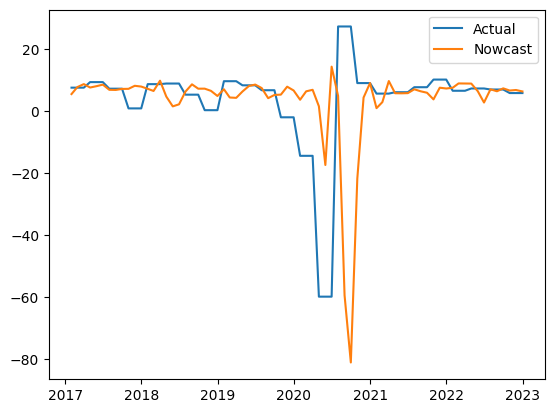

In [64]:
@ray.remote
def evaluate_one_vintage_ray(vintage_id, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, target=target):
    configs = []
    results_dir = os.path.join(os.getcwd(), "ray_results", "singletask_biasTEoptuna2", f"{vintage_id.strftime('%Y-%m')}")
    restored_tuner = ray.tune.Tuner.restore(
        results_dir,
        trainable=ray.tune.with_parameters(
            partial(train_model, vintage=vintage_id, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, task='singletask')
        )
    )
    ray_results = restored_tuner.get_results()
    best_result = ray_results.get_best_result("val_loss_y", "min", "all")
    ckpt_path = f'{best_result.get_best_checkpoint(metric="val_loss_y", mode="min").path}/checkpoint'
    result = evaluate_one_vintage_ST(
        vintage_id,
        with_econ=with_econ,
        with_tweets=with_tweets,
        kmpair=kmpair,
        target=target,
        config=best_result.config,
        ckpt_path=ckpt_path
    )
    print(f"Vintage: {vintage_id.strftime('%Y-%m')}", "Config:", best_result.config, "Epoch: ", best_result.get_best_checkpoint(metric='val_loss_y', mode='min').path.split('/')[-1])
    configs.append([f"{vintage_id.strftime('%Y-%m')}", best_result.config, ckpt_path.split('/')[-2]])
    return result, configs

vintage_ids = list(pd.date_range(start="2017-01-31", end="2023-01-01", freq="ME"))
# vintage_ids = list(pd.date_range(start="2020-01-31", end="2022-01-01", freq="ME"))
futures = [evaluate_one_vintage_ray.remote(v) for v in vintage_ids]
results= ray.get(futures)

nowcast_results = []
configs = []
for result, config in results:
    nowcast_results.append(result)
    configs.append(config)
for c in configs:
    print(c)
results_df = pd.DataFrame(nowcast_results, columns=["Vintage", "Nowcast"])
results_df = results_df.set_index("Vintage")
gdp = pd.read_csv('Results/DFM_Opt_1010_W1000_PHL_GDP_SA_E_L1-0_L2-0_summary.csv', parse_dates=['date'], index_col=[0])[['Actual_Q']]
results_df = pd.concat([results_df, gdp], axis=1).dropna()
# results_df.to_csv('results_T_e150_w27.csv')
print("RMSE:", np.sqrt(mean_squared_error(results_df['Actual_Q'], results_df['Nowcast'])))
# Compute RMSE for each month in the quarter
for i, label in enumerate(['First', 'Second', 'Third']):
    mask = results_df.index.month % 3 == (i + 1) % 3
    rmse = np.sqrt(mean_squared_error(results_df.loc[mask, 'Actual_Q'], results_df.loc[mask, 'Nowcast']))
    print(f"RMSE for {label} month in quarter: {rmse:.4f}")
display(results_df)
results_df.to_csv('Results/ST_BiasTE_2y.csv')
plt.plot(results_df.index, results_df['Actual_Q'], label='Actual')
plt.plot(results_df.index, results_df['Nowcast'], label='Nowcast')
plt.legend()

In [23]:
results_df.iloc[30:]

,Nowcast,Actual_Q
2019-07-31,7.367528,6.653630
2019-08-31,3.312229,6.653630
2019-09-30,6.095869,6.653630
2019-10-31,7.250449,-2.066192
2019-11-30,6.188606,-2.066192
2019-12-31,6.027480,-2.066192
2020-01-31,2.422618,-14.473814
2020-02-29,9.359542,-14.473814
2020-03-31,5.875410,-14.473814
2020-04-30,3.720092,-59.836421


# Multi Task

In [ ]:
fixed_params = {
    'vintage': pd.to_datetime('2020-06-30'),
    'kmpair': {'PE': ['CR_G0','CR_B0']},
    'with_econ': True,
    'with_tweets': False
}
param_space = {'learning_rate': 1e-1, 'weight_decay': 1e-3, 'alpha': 100, 'epochs': 200, 'num_layers':2, 'data_window': 72} # 72, 108, 
# pl.seed_everything(42, workers=True)
train_model(config=param_space, **fixed_params,
            task='multitask', logger_enabled=True, device='cpu') # ckpt_path = 'lightning_logs/version_0/checkpoints/last.ckpt'

In [16]:
vintage = pd.to_datetime('2018-01-31')
kmpair = {'PE': ['VADERstanceweight_log_stl'], 'PU+': ['CR_lognorm']}
with_econ = True
with_tweets = True

tuner = ray.tune.Tuner(
    ray.tune.with_parameters(partial(train_model, vintage=vintage, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, task='multitask')),
    param_space={
        # "learning_rate": ray.tune.grid_search([1e-1, 1e-2]),
        # "weight_decay": ray.tune.grid_search([1e-3, 1e-4]),
        # "alpha": ray.tune.grid_search([0.1, 1, 10, 20, 100]),
        # "num_layers": ray.tune.grid_search([1, 2]),
        # "data_window": ray.tune.grid_search([3, 12, 36, 72]),
        "epochs": ray.tune.choice([150]),
        "learning_rate": ray.tune.loguniform(1e-3, 1e-1),
        "weight_decay": ray.tune.loguniform(1e-4, 1e-2),
        # "alpha": ray.tune.choice([0.01, 0.1, 1, 10, 20, 100]),
        "alpha": ray.tune.loguniform(1e-2, 1e2),
        "num_layers": ray.tune.choice([1, 2]),
        "data_window": ray.tune.choice([3, 6, 12, 24, 36, 48, 60, 72]),
        },
    tune_config=ray.tune.TuneConfig(
        metric="val_loss_y",
        mode="min",
        num_samples=48,
        search_alg=ConcurrencyLimiter(OptunaSearch(metric="val_loss_y",mode="min"), max_concurrent=48),
    ),
    run_config=ray.tune.RunConfig(
        name=f"{vintage.strftime('%Y-%m')}-nobiasTEoptuna2y1x",
        storage_path="/home/btiu/Documents/Research/TweetsNowcast/ray_results/multitask_sample",
        verbose=1,
        checkpoint_config=ray.tune.CheckpointConfig(num_to_keep=1, checkpoint_score_attribute="val_loss_y", checkpoint_score_order="min"), # Slows down training
    ),
)
pl.seed_everything(42, workers=True)
results = tuner.fit()

In [17]:
best_result = results.get_best_result("val_loss_y", "min", "all")
print(f'Best trial config: {best_result.config}', best_result.get_best_checkpoint(metric="val_loss_y", mode="min").path.split('/')[-1])
# display(results.get_dataframe().sort_values(by='val_loss_y', ascending=True).head(5))

Best trial config: {'epochs': 150, 'learning_rate': 0.024866667576353512, 'weight_decay': 0.0017308980944365378, 'alpha': 99.18962899856407, 'num_layers': 1, 'data_window': 48} checkpoint_000103


In [5]:
class MyTrainable(tune.Trainable):
    def setup(self, config):
        self.vintage = config.get("vintage")
        self.with_econ = config.get("with_econ")
        self.with_tweets = config.get("with_tweets")
        self.data_window = config.get("data_window")
        self.kmpair = config.get("kmpair")
        self.task = config.get("task")
        self.ckpt_path = config.get("ckpt_path")
        self.logger_enabled = config.get("logger", False)
        self.config = config
        
        pl.seed_everything(42, workers=True)
        self.train_loader, self.val_loader, _,_,_ = get_dataloader_for_vintage(self.vintage, self.with_econ, self.with_tweets, self.data_window, self.kmpair, self.task)
        if self.task == "singletask":
            print("Training single task model...")
        elif self.task == "multitask":
            self.model = MTMFSeq2OneLightning(
                dim_x=self.train_loader.dataset.tensors[0].shape[-1], # type: ignore
                dim_y=self.train_loader.dataset.tensors[1].shape[-1], # type: ignore
                num_layers=self.config['num_layers'],
                learning_rate=self.config["learning_rate"],
                weight_decay=self.config["weight_decay"],
                alpha=self.config['alpha']
            )
        checkpoint_callback = ModelCheckpoint(monitor="val_loss_y", mode="min", save_top_k=1, save_last=True)
        lr_monitor = LearningRateMonitor(logging_interval='step')
        tune_callbacks = [TuneReportCheckpointCallback(metrics={'val_loss_y': 'val_loss_y', 'val_loss_x': 'val_loss_x', 'train_loss': 'train_loss'}, on="validation_end")]
        if self.logger_enabled:
            tune_callbacks.extend([checkpoint_callback, lr_monitor])
        trainer = pl.Trainer(
            max_epochs=self.config['epochs'],
            callbacks=[tune_callbacks],
            # strategy=RayDDPStrategy(),
            # plugins=[RayLightningEnvironment()],
            enable_checkpointing=self.logger_enabled,
            deterministic=True,
            accelerator='cpu',
            num_sanity_val_steps=0,
            enable_progress_bar=False,
            enable_model_summary=False,
            logger=self.logger_enabled,
            log_every_n_steps=1 if self.logger_enabled else 50
        )
        # self.trainer = prepare_trainer(trainer)
        self.trained_once = False # Flag to track if trainer.fit has completed
        # self.current_epoch = 0
    def step(self):
        # if self.ckpt_path is not None:
        #     self.trainer.fit(self.model, self.train_loader, self.val_loader, ckpt_path=self.ckpt_path)
        # else:
        #     self.trainer.fit(self.model, self.train_loader, self.val_loader)
        if not self.trained_once:
            self.trainer.fit(self.model, self.train_loader, self.val_loader)
            self.trained_once = True # Mark as trained
        # self.current_epoch += 1
        reported_metrics = {
            'val_loss_y': self.trainer.callback_metrics.get('val_loss_y').item(),
            'val_loss_x': self.trainer.callback_metrics.get('val_loss_x').item(),
            'train_loss': self.trainer.callback_metrics.get('train_loss').item(),
            # "epochs_completed": self.trainer.current_epoch
        }
        # # Convert tensor values to Python floats if necessary
        # for key, value in reported_metrics.items():
        #     if isinstance(value, torch.Tensor):
        #         reported_metrics[key] = value.item()
        #     elif value is None: # Handle cases where a metric might not be logged (e.g., no validation)
        #         reported_metrics[key] = float('nan') # Or a default like 0.0 or 1e9 for losses
        return {"done": True, **reported_metrics}
        # return {"epoch": self.current_epoch, **reported_metrics} # "done": self.current_epoch >= self.config['epochs']

    def save_checkpoint(self, checkpoint_dir):
        path = os.path.join(checkpoint_dir, "model.ckpt")
        self.trainer.save_checkpoint(path)
        return checkpoint_dir

    def load_checkpoint(self, checkpoint_path):
        self.model = self.model.load_from_checkpoint(
            checkpoint_path=os.path.join(checkpoint_path, "model.ckpt"),
            dim_x=self.train_loader.dataset.tensors[0].shape[-1],
            dim_y=self.train_loader.dataset.tensors[1].shape[-1],
            num_layers=self.config['num_layers'],
            learning_rate=self.config["learning_rate"],
            weight_decay=self.config["weight_decay"],
            alpha=self.config['alpha']
        )
        # Set trained_once to False so it runs trainer.fit again if needed
        self.trained_once = False
        # self.trainer.fit_loop.max_epochs = self.config['epochs'] # Reset max_epochs for Trainer if needed
        # self.trainer.fit_loop.epoch_progress.current = self.trainer.current_epoch # Ensure internal epoch state is correct
    def cleanup(self):
        """
        Cleans up resources after the trial finishes.
        """
        del self.trainer
        del self.model
        del self.train_loader
        del self.val_loader

In [ ]:
search_space = {
    "learning_rate": tune.loguniform(1e-3, 1e-1),
    "weight_decay": tune.loguniform(1e-5, 1e-3),
    "alpha": tune.uniform(0.1, 0.9),
    "epochs": 100,
    "num_layers": tune.grid_search([1, 2, 3])
}
fixed_params = {
    "vintage": pd.to_datetime('2020-06-30'),
    "with_econ": True,
    "with_tweets": False,
    "data_window": 12,
    "kmpair": {'PE': ['CR_G0','CR_B0']},
    "task": "multitask", # Or "single_task"
    "logger": False
}
tuner = tune.Tuner(
    MyTrainable,
    param_space={**search_space, **fixed_params},
    tune_config=tune.TuneConfig(
        metric="val_loss_y",
        mode="min",
        num_samples=5,
    ),
    run_config=tune.RunConfig(
        name=f"{fixed_params['vintage'].strftime('%Y-%m')}",
        storage_path="/home/btiu/Documents/Research/TweetsNowcast/ray_results/multitask_sample",
        verbose=1,
        stop={"epoch": 50},
        checkpoint_config=tune.CheckpointConfig(num_to_keep=1, checkpoint_score_attribute="val_loss_y", checkpoint_score_order="min"),
    ),
)
results = tuner.fit()
print("Best trial config:", results.get_best_result().config)
print("Best trial metrics:", results.get_best_result().metrics)

## Evaluation

### Evaluate one vintage

In [ ]:
target = 'PHL_GDP_SA'
vintage = pd.to_datetime('2020-06-30')
with_econ = True
with_tweets = True
kmpair = {'PE':['VADERstanceweight_log_stl', 'VADERraw']}

config = {'num_layers':2, 'data_window': 12}
ckpt_path = 'lightning_logs/version_1/checkpoints/last.ckpt' # 'checkpoints/vintage_2020-06-30/model.ckpt'
evaluate_one_vintage_MT(vintage, with_econ=with_econ, with_tweets=with_tweets, kmpair = kmpair, target=target, ckpt_path=ckpt_path, config=config)

NameError: name 'pd' is not defined

In [19]:
target = 'PHL_GDP_SA'
vintage_id = pd.to_datetime('2018-01-31')
with_econ = True
with_tweets = True
kmpair = {'PE':['VADERstanceweight_log_stl', 'VADERraw']}

results_dir=os.path.join(os.getcwd(), "ray_results", "multitask_sample/", f"{vintage_id.strftime('%Y-%m')}-nobiasTEoptuna2y1x")
restored_tuner = ray.tune.Tuner.restore(results_dir, trainable=ray.tune.with_parameters(partial(train_model, task='multitask')))
ray_results = restored_tuner.get_results()
best_result = ray_results.get_best_result("val_loss_y", "min", "all")
ckpt_path = f'{best_result.get_best_checkpoint(metric="val_loss_y", mode="min").path}/checkpoint'
print(best_result.config, ckpt_path.split('/')[-2])
evaluate_one_vintage_MT(vintage_id, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, target=target, ckpt_path=ckpt_path, config=best_result.config)

{'epochs': 150, 'learning_rate': 0.024866667576353512, 'weight_decay': 0.0017308980944365378, 'alpha': 99.18962899856407, 'num_layers': 1, 'data_window': 48} checkpoint_000103


(Timestamp('2018-01-31 00:00:00'),
 np.float32(7.1308737),
 np.float32(7.1308737))

,val_loss_y,training_iteration,config/learning_rate,config/weight_decay,config/alpha,config/data_window,config/num_layers
17,83.943123,150,0.01,0,1.00,12,2
18,88.568085,150,0.01,0,100.00,12,2
12,89.810555,147,0.01,0,10.00,12,2
23,95.519997,59,0.01,0,20.00,12,2
10,96.226967,150,0.01,0,0.01,12,2


Text(0.5, 1.0, 'best_result: 0.010, 1, 0.00000')

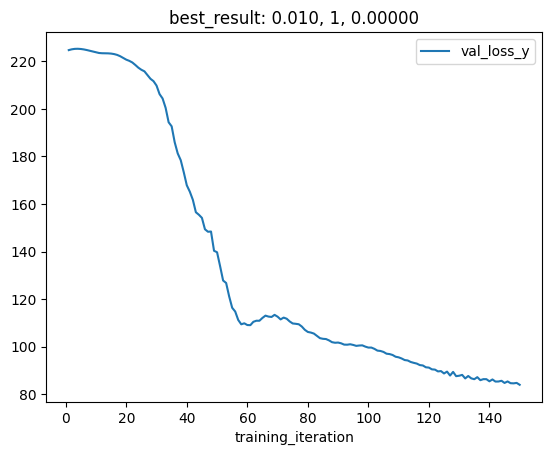

In [10]:
result_df = ray_results.get_dataframe(filter_metric="val_loss_y", filter_mode="min") # use get_dataframe() to get final iteration results
display(result_df[["val_loss_y","training_iteration","config/learning_rate", "config/weight_decay","config/alpha", "config/data_window", "config/num_layers"]].sort_values(by='val_loss_y', ascending=True).head(5))


plot = best_result.metrics_dataframe.plot("training_iteration", "val_loss_y") ### Plotting the best result's validation loss over training iterations
plot.set_title(f"best_result: {best_result.config['learning_rate']:.3f}, {best_result.config['alpha']}, {best_result.config['weight_decay']:.5f}")
# ax = None
# for result in ray_results:
#     label = f"lr={result.config['learning_rate']:.3f}, a={result.config['alpha']}, wd={result.config['weight_decay']:.3f}"
#     if ax is None:
#         ax = result.metrics_dataframe.plot("training_iteration", "val_loss_y", label=label)
#     else:
#         result.metrics_dataframe.plot("training_iteration", "val_loss_y", ax=ax, label=label)
# ax.set_title("Mean Accuracy vs. Training Iteration for All Trials")
# ax.set_ylabel("Mean Test Accuracy")

### Evaluate multiple vintages

In [65]:
target = 'PHL_GDP_SA'
# kmpair = {'PE': ['CR_G0','CR_B0']}
kmpair = {'PE': ['VADERstanceweight_log_stl'], 'PU+': ['CR_lognorm']}
with_econ = True
with_tweets = True

[['2017-01', {'epochs': 150, 'learning_rate': 0.04892981273636215, 'weight_decay': 0.008644885091397624, 'alpha': 3.4401640385566328, 'num_layers': 2, 'data_window': 36}, 'checkpoint_000037']]
[['2017-02', {'epochs': 150, 'learning_rate': 0.05111305903136226, 'weight_decay': 0.0069709415287893175, 'alpha': 1.5147112886846592, 'num_layers': 1, 'data_window': 24}, 'checkpoint_000121']]
[['2017-03', {'epochs': 150, 'learning_rate': 0.05135570597988677, 'weight_decay': 0.00015875657987813937, 'alpha': 0.16790139803697438, 'num_layers': 2, 'data_window': 72}, 'checkpoint_000054']]
[['2017-04', {'epochs': 150, 'learning_rate': 0.06988134947791712, 'weight_decay': 0.0012264931794561406, 'alpha': 3.0581579027760983, 'num_layers': 1, 'data_window': 48}, 'checkpoint_000087']]
[['2017-05', {'epochs': 150, 'learning_rate': 0.01761759876633024, 'weight_decay': 0.00035788354864972876, 'alpha': 1.1285074479316977, 'num_layers': 1, 'data_window': 24}, 'checkpoint_000023']]
[['2017-06', {'epochs': 150,

,Nowcast_0,Nowcast_1,Actual_Q
2017-01-31,4.841246,8.395751,7.481528
2017-02-28,6.649252,6.649252,7.481528
2017-03-31,6.633732,11.009307,7.481528
2017-04-30,6.643574,6.579760,9.267269
2017-05-31,7.593159,7.610321,9.267269
...,...,...,...
2022-08-31,7.109812,7.108214,6.886408
2022-09-30,6.665214,7.777479,6.886408
2022-10-31,3.167074,5.780418,5.740342
2022-11-30,5.940276,6.202762,5.740342


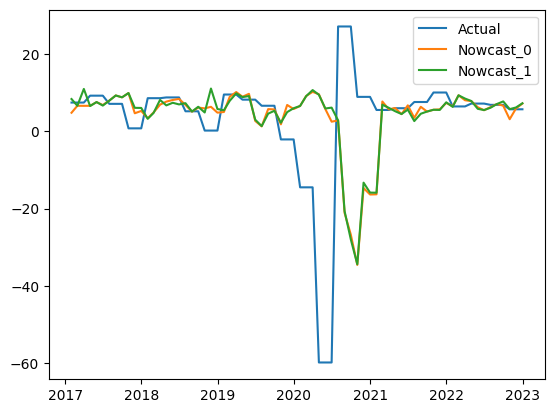

In [50]:
@ray.remote
def evaluate_one_vintage_ray(vintage_id, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, target=target):
    configs = []
    results_dir = os.path.join(os.getcwd(), "ray_results", "multitask_nobiasTEoptuna4y1x", f"{vintage_id.strftime('%Y-%m')}")
    restored_tuner = ray.tune.Tuner.restore(
        results_dir,
        trainable=ray.tune.with_parameters(
            partial(train_model, vintage=vintage_id, with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair, task='multitask')
        )
    )
    ray_results = restored_tuner.get_results()
    best_result = ray_results.get_best_result("val_loss", "min", "all")
    ckpt_path = f'{best_result.get_best_checkpoint(metric="val_loss", mode="min").path}/checkpoint'
    result = evaluate_one_vintage_MT(
        vintage_id,
        with_econ=with_econ,
        with_tweets=with_tweets,
        kmpair=kmpair,
        target=target,
        config=best_result.config,
        ckpt_path=ckpt_path
    )
    print(f"Vintage: {vintage_id.strftime('%Y-%m')}", "Config:", best_result.config, "Epoch: ", best_result.get_best_checkpoint(metric='val_loss', mode='min').path.split('/')[-1])
    configs.append([f"{vintage_id.strftime('%Y-%m')}", best_result.config, ckpt_path.split('/')[-2]])
    return result, configs

vintage_ids = list(pd.date_range(start="2017-01-31", end="2023-01-01", freq="ME"))
# vintage_ids = list(pd.date_range(start="2020-01-31", end="2022-01-01", freq="ME"))
futures = [evaluate_one_vintage_ray.remote(v) for v in vintage_ids]
results= ray.get(futures)

nowcast_results = []
configs = []
for result, config in results:
    nowcast_results.append(result)
    configs.append(config)
for c in configs:
    print(c)
results_df = pd.DataFrame(nowcast_results, columns=["Vintage", "Nowcast_0", "Nowcast_1"])
results_df = results_df.set_index("Vintage")
gdp = pd.read_csv('Results/DFM_Opt_1010_W1000_PHL_GDP_SA_E_L1-0_L2-0_summary.csv', parse_dates=['date'], index_col=[0])[['Actual_Q']]
results_df = pd.concat([results_df, gdp], axis=1).dropna()
# results_df.to_csv('results_T_e150_w27.csv')
print("nowcast_0:", np.sqrt(mean_squared_error(results_df['Actual_Q'], results_df['Nowcast_0'])), "nowcast_1:", np.sqrt(mean_squared_error(results_df['Actual_Q'], results_df['Nowcast_1'])))
for i, label in enumerate(['First', 'Second', 'Third']):
    mask = results_df.index.month % 3 == (i + 1) % 3
    rmse_0 = np.sqrt(mean_squared_error(results_df.loc[mask, 'Actual_Q'], results_df.loc[mask, 'Nowcast_0']))
    rmse_1 = np.sqrt(mean_squared_error(results_df.loc[mask, 'Actual_Q'], results_df.loc[mask, 'Nowcast_1']))
    print(f"RMSE for {label} month in quarter: {rmse_0:.4f}, {rmse_1:.4f}")
display(results_df)
results_df.to_csv('Results/MT_NoBiasTE_4y1x.csv')
plt.plot(results_df.index, results_df['Actual_Q'], label='Actual')
plt.plot(results_df.index, results_df['Nowcast_0'], label='Nowcast_0')
plt.plot(results_df.index, results_df['Nowcast_1'], label='Nowcast_1')
plt.legend()

In [15]:
results_df.iloc[36:]

,Nowcast_0,Nowcast_1,Actual_Q
2020-01-31,8.887242,6.989429,-14.473814
2020-02-29,9.496764,9.425505,-14.473814
2020-03-31,9.497416,8.153235,-14.473814
2020-04-30,7.317539,7.039020,-59.836421
2020-05-31,-2.523804,8.138317,-59.836421
2020-06-30,3.355215,3.335329,-59.836421
2020-07-31,5.972723,4.061923,27.186663
2020-08-31,0.751780,0.715585,27.186663
2020-09-30,0.712093,0.713554,27.186663
2020-10-31,0.745152,0.718500,8.953196
